In [ ]:
!pip install nltk wordcloud scikit-learn seaborn matplotlib pandas scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re, nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon')
nltk.download('stopwords')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/debasmitbora/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/debasmitbora/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 🎨 Global Theme — Black / White / Pink

In [3]:
BG      = '#000000'
FG      = '#ffffff'
#PINK    = '#ff69b4'
PINK = '#df4264'
PINK_LO = '#ff69b440'

mpl.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    FG,
    'axes.labelcolor':   FG,
    'text.color':        FG,
    'xtick.color':       FG,
    'ytick.color':       FG,
    'grid.color':        '#333333',
    'legend.facecolor':  BG,
    'legend.edgecolor':  FG,
})

def styled_fig(w=10, h=5):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(FG)
        spine.set_linewidth(1.5)
    return fig, ax

print("✅ Theme configured!")

✅ Theme configured!


## 📂 Load & Clean Data

In [4]:


df = pd.read_csv('train.csv')
print(f"✅ Loaded — shape: {df.shape}")
df.head(3)

✅ Loaded — shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_comment'] = df['comment_text'].apply(clean_text)
df['clean_comment'].fillna('', inplace=True)
print("✅ Text cleaning complete!")
print(df[['comment_text', 'clean_comment']].head(3))

✅ Text cleaning complete!
                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   

                                       clean_comment  
0  explanation why the edits made under my userna...  
1  daww he matches this background colour im seem...  
2  hey man im really not trying to edit war its j...  


## ⚙️ Feature Engineering

In [6]:
toxicity_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df['toxicity_score']   = df[toxicity_cols].sum(axis=1)
df['engagement_proxy'] = df['clean_comment'].apply(len)

sid = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['clean_comment'].apply(
    lambda x: sid.polarity_scores(x)['compound'])

print("✅ Feature Engineering Complete!")
print(df['toxicity_score'].value_counts().sort_index())

✅ Feature Engineering Complete!
toxicity_score
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64


## 📊 Chart 1 — Toxicity Score Distribution

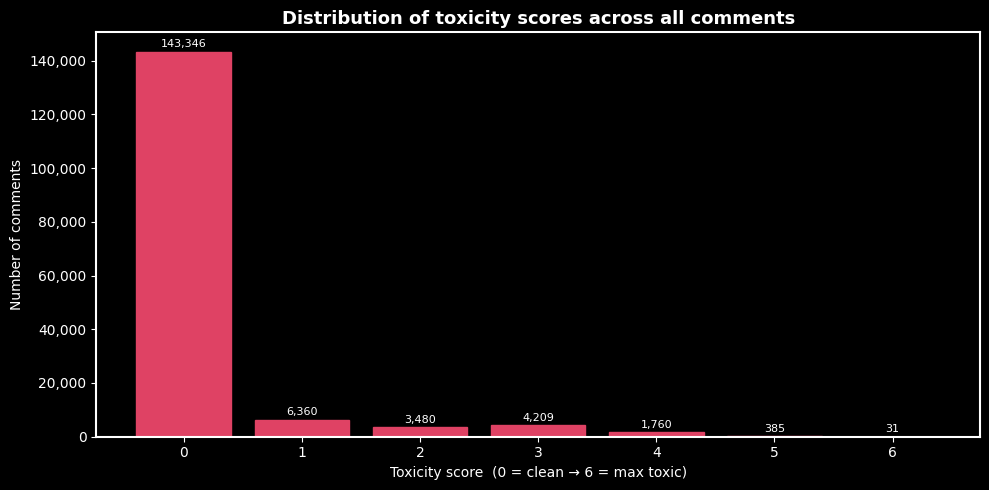

✅ Saved: chart1_toxicity_distribution.png


In [7]:
fig, ax = styled_fig(10, 5)
counts = df['toxicity_score'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=PINK, edgecolor=PINK)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8, color=FG)

ax.set_title('Distribution of toxicity scores across all comments',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Toxicity score  (0 = clean → 6 = max toxic)', color=FG)
ax.set_ylabel('Number of comments', color=FG)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(sorted(df['toxicity_score'].unique()))
plt.tight_layout()
plt.savefig('chart1_toxicity_distribution.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart1_toxicity_distribution.png")

## 📊 Chart 2 — Per-Label Prevalence

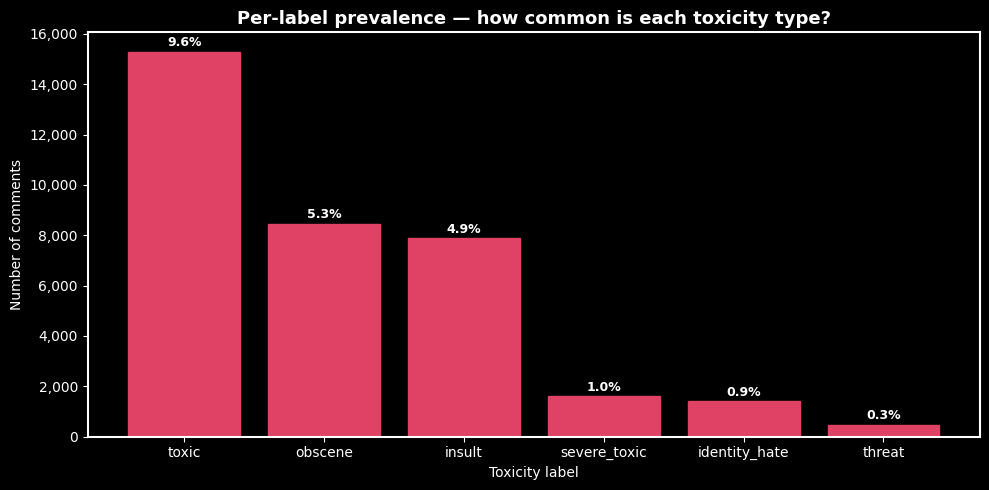

✅ Saved: chart2_label_prevalence.png


In [8]:
label_counts = df[toxicity_cols].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)

fig, ax = styled_fig(10, 5)
bars = ax.bar(label_counts.index, label_counts.values, color=PINK, edgecolor=PINK)

for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=FG)

ax.set_title('Per-label prevalence — how common is each toxicity type?',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Toxicity label', color=FG)
ax.set_ylabel('Number of comments', color=FG)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('chart2_label_prevalence.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart2_label_prevalence.png")

## 📊 Chart 3 — Label Co-occurrence Heatmap

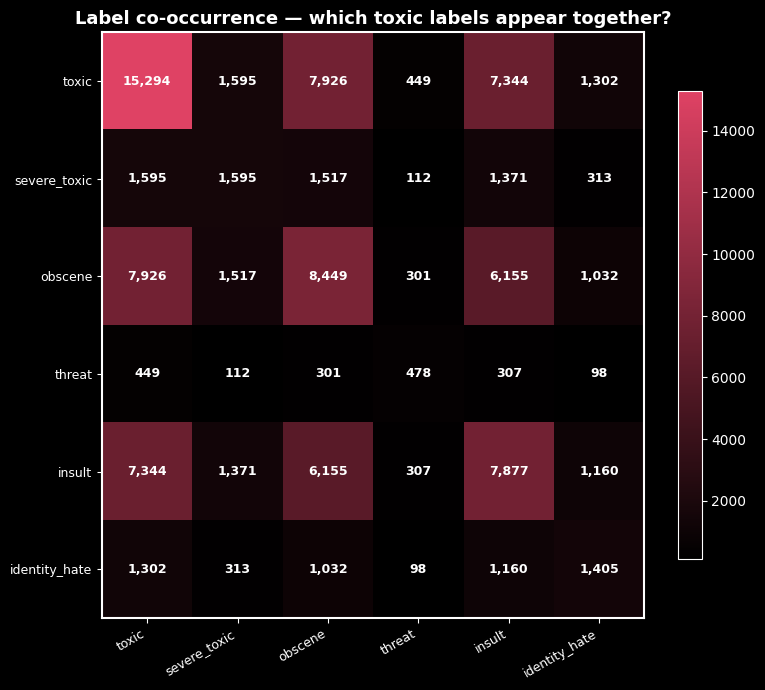

✅ Saved: chart3_label_cooccurrence.png


In [19]:
toxic_df = df[df['toxicity_score'] > 0][toxicity_cols]
cooccur  = toxic_df.T.dot(toxic_df)

#pink_cmap = LinearSegmentedColormap.from_list('pk', ['#000000', '#ff69b4'], N=256)

pink_cmap = LinearSegmentedColormap.from_list('pk', ['#000000', '#df4264'], N=256)

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

im = ax.imshow(cooccur.values, cmap=pink_cmap, aspect='auto')
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.ax.yaxis.set_tick_params(color=FG)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

for i in range(len(toxicity_cols)):
    for j in range(len(toxicity_cols)):
        ax.text(j, i, f'{cooccur.values[i,j]:,}',
                ha='center', va='center', fontsize=9, color=FG, fontweight='bold')

ax.set_xticks(range(len(toxicity_cols)))
ax.set_yticks(range(len(toxicity_cols)))
ax.set_xticklabels(toxicity_cols, color=FG, fontsize=9, rotation=30, ha='right')
ax.set_yticklabels(toxicity_cols, color=FG, fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(FG); spine.set_linewidth(1.5)

ax.set_title('Label co-occurrence — which toxic labels appear together?',
             color=FG, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_label_cooccurrence.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart3_label_cooccurrence.png")

## 📊 Chart 4 — Toxicity Score vs Engagement (Box Plot)

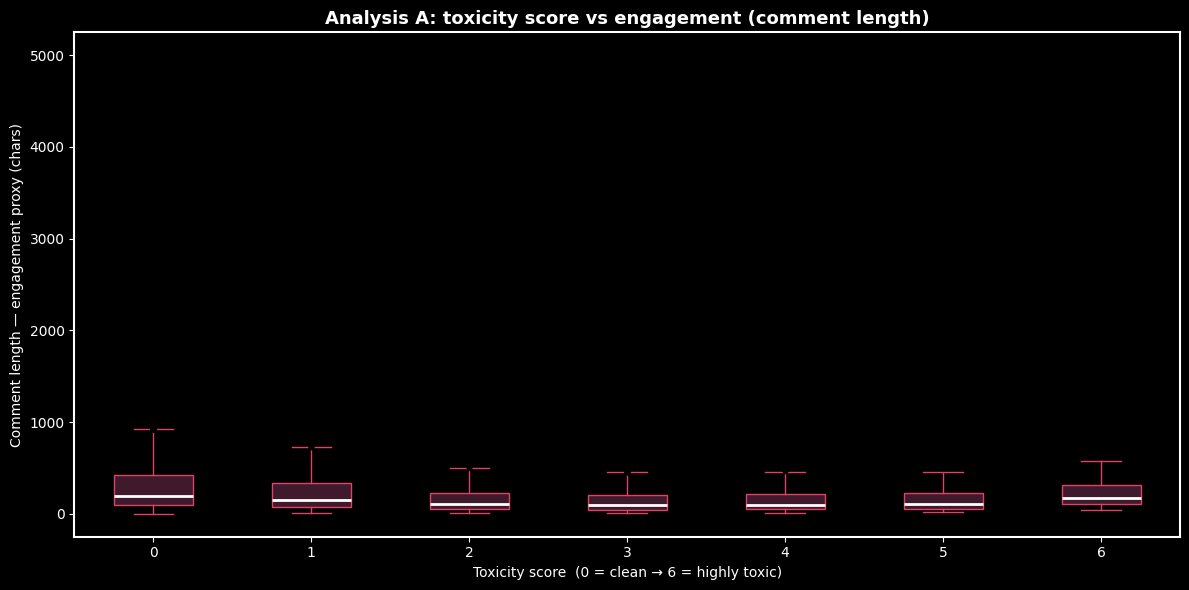


📊 Average engagement by toxicity score:
toxicity_score
0    376.95
1    323.88
2    232.50
3    223.46
4    344.29
5    339.77
6    352.29
Name: engagement_proxy, dtype: float64
✅ Saved: chart4_toxicity_vs_engagement.png


In [10]:
fig, ax = styled_fig(12, 6)

groups  = sorted(df['toxicity_score'].unique())
data_bp = [df[df['toxicity_score'] == g]['engagement_proxy'].values for g in groups]

ax.boxplot(data_bp, positions=groups, patch_artist=True,
           medianprops=dict(color=FG, linewidth=2),
           boxprops=dict(facecolor=PINK_LO, edgecolor=PINK),
           whiskerprops=dict(color=PINK),
           capprops=dict(color=PINK),
           flierprops=dict(marker='o', color=PINK, alpha=0.3, markersize=3))

ax.set_title('Analysis A: toxicity score vs engagement (comment length)',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Toxicity score  (0 = clean → 6 = highly toxic)', color=FG)
ax.set_ylabel('Comment length — engagement proxy (chars)', color=FG)
ax.set_xticks(groups)

plt.tight_layout()
plt.savefig('chart4_toxicity_vs_engagement.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

print("\n📊 Average engagement by toxicity score:")
print(df.groupby('toxicity_score')['engagement_proxy'].mean().round(2))
print("✅ Saved: chart4_toxicity_vs_engagement.png")

## 📊 Chart 5 — Sentiment Score vs Toxicity (Box Plot)

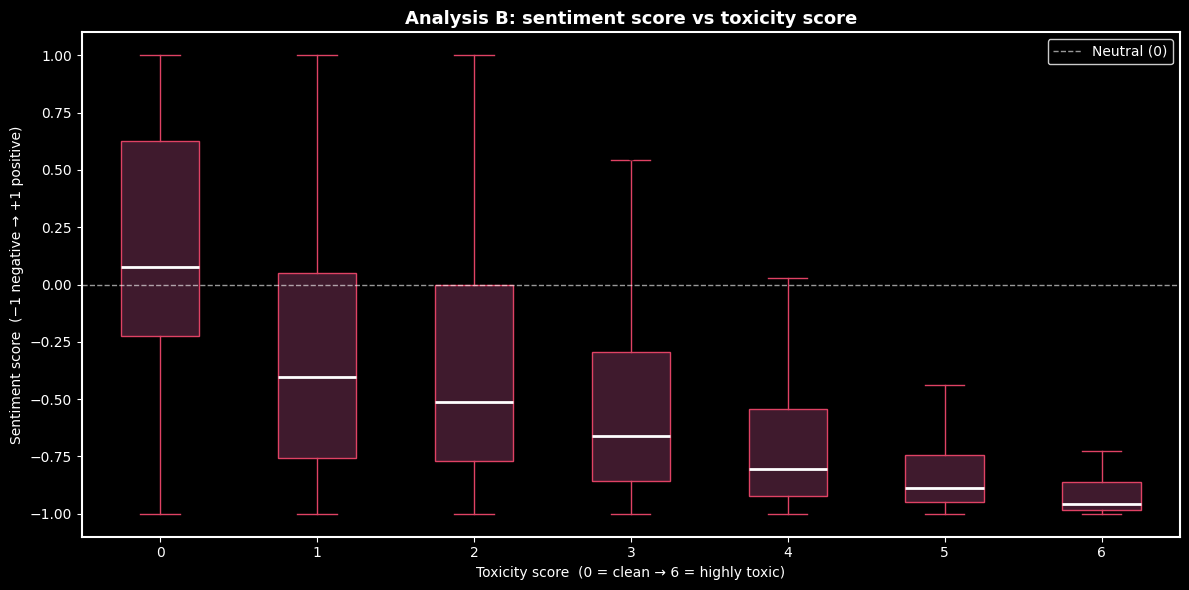


📊 Average sentiment by toxicity score:
toxicity_score
0    0.1490
1   -0.2720
2   -0.3482
3   -0.5109
4   -0.6543
5   -0.7816
6   -0.9056
Name: sentiment_score, dtype: float64
✅ Saved: chart5_sentiment_vs_toxicity.png


In [11]:
fig, ax = styled_fig(12, 6)

data_sent = [df[df['toxicity_score'] == g]['sentiment_score'].values for g in groups]

ax.boxplot(data_sent, positions=groups, patch_artist=True,
           medianprops=dict(color=FG, linewidth=2),
           boxprops=dict(facecolor=PINK_LO, edgecolor=PINK),
           whiskerprops=dict(color=PINK),
           capprops=dict(color=PINK),
           flierprops=dict(marker='o', color=PINK, alpha=0.3, markersize=3))

ax.axhline(0, color=FG, linestyle='--', linewidth=1, alpha=0.6, label='Neutral (0)')
ax.set_title('Analysis B: sentiment score vs toxicity score',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Toxicity score  (0 = clean → 6 = highly toxic)', color=FG)
ax.set_ylabel('Sentiment score  (−1 negative → +1 positive)', color=FG)
ax.set_xticks(groups)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG)

plt.tight_layout()
plt.savefig('chart5_sentiment_vs_toxicity.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

print("\n📊 Average sentiment by toxicity score:")
print(df.groupby('toxicity_score')['sentiment_score'].mean().round(4))
print("✅ Saved: chart5_sentiment_vs_toxicity.png")

## 📊 Chart 6 — Sentiment KDE Distribution

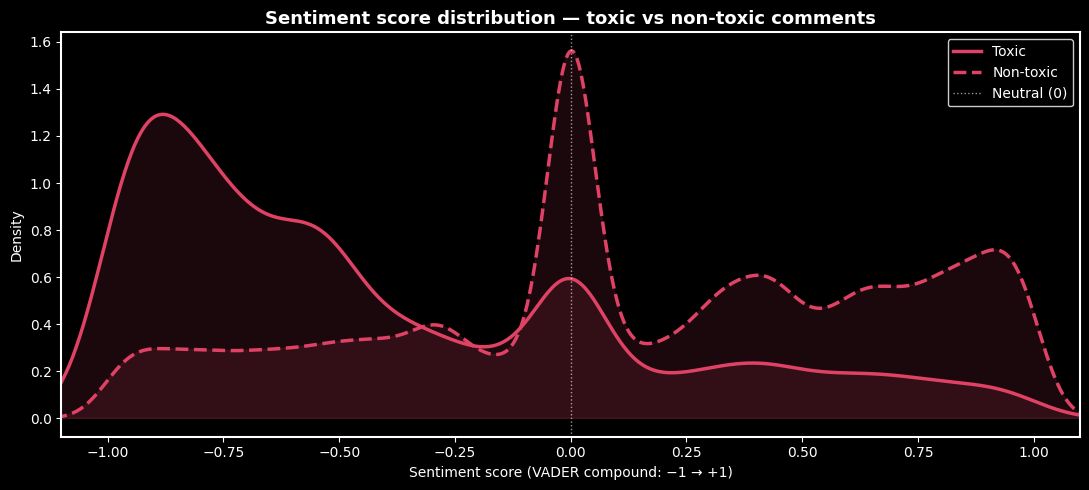

✅ Saved: chart6_sentiment_kde.png


In [12]:
fig, ax = styled_fig(11, 5)

df[df['toxicity_score'] > 0]['sentiment_score'].plot.kde(
    ax=ax, color=PINK, linewidth=2.5, label='Toxic')

df[df['toxicity_score'] == 0]['sentiment_score'].plot.kde(
    ax=ax, color=PINK, linewidth=2.5, linestyle='--', label='Non-toxic')

# shade under curves
for line in ax.lines:
    xd, yd = line.get_xdata(), line.get_ydata()
    ax.fill_between(xd, yd, alpha=0.12, color=PINK)

ax.axvline(0, color=FG, linestyle=':', linewidth=1, alpha=0.6, label='Neutral (0)')
ax.set_title('Sentiment score distribution — toxic vs non-toxic comments',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment score (VADER compound: −1 → +1)', color=FG)
ax.set_ylabel('Density', color=FG)
ax.set_xlim(-1.1, 1.1)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG)

plt.tight_layout()
plt.savefig('chart6_sentiment_kde.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart6_sentiment_kde.png")

## 📊 Chart 7 — Word Clouds (Toxic vs Non-Toxic)

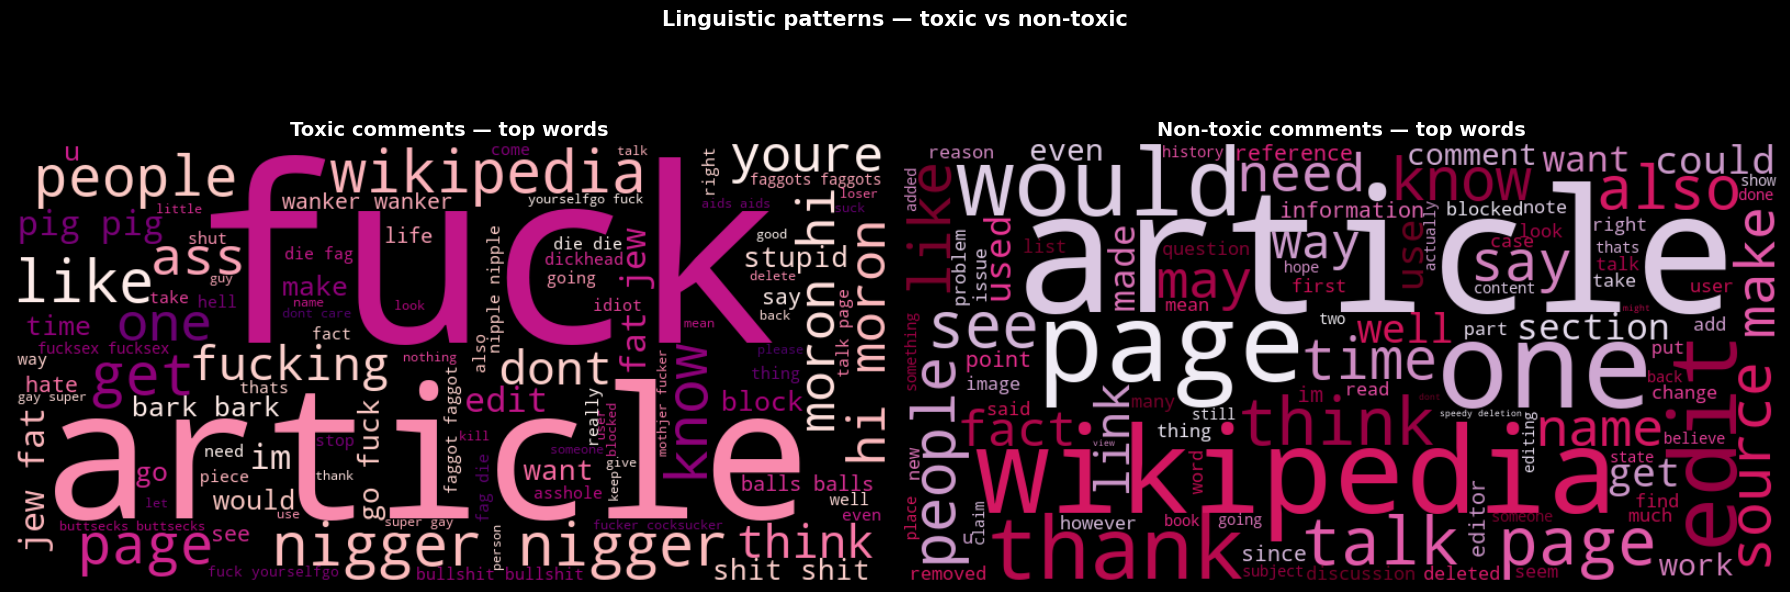

✅ Saved: chart7_wordclouds.png


In [13]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

toxic_text     = ' '.join(df[df['toxicity_score'] > 0]['clean_comment'].dropna())
clean_text_wc  = ' '.join(df[df['toxicity_score'] == 0]['clean_comment'].dropna())

wc_toxic = WordCloud(width=800, height=400, background_color='black',
                     colormap='RdPu', stopwords=stop_words, max_words=100).generate(toxic_text)
wc_clean = WordCloud(width=800, height=400, background_color='black',
                     colormap='PuRd', stopwords=stop_words, max_words=100).generate(clean_text_wc)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG)
for ax_ in axes:
    ax_.set_facecolor(BG)
    for spine in ax_.spines.values():
        spine.set_edgecolor(FG); spine.set_linewidth(1.5)

axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].set_title('Toxic comments — top words', color=FG, fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_clean, interpolation='bilinear')
axes[1].set_title('Non-toxic comments — top words', color=FG, fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Linguistic patterns — toxic vs non-toxic', color=FG, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_wordclouds.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart7_wordclouds.png")

## 📊 Chart 8 — Top 15 Words (Toxic vs Non-Toxic)

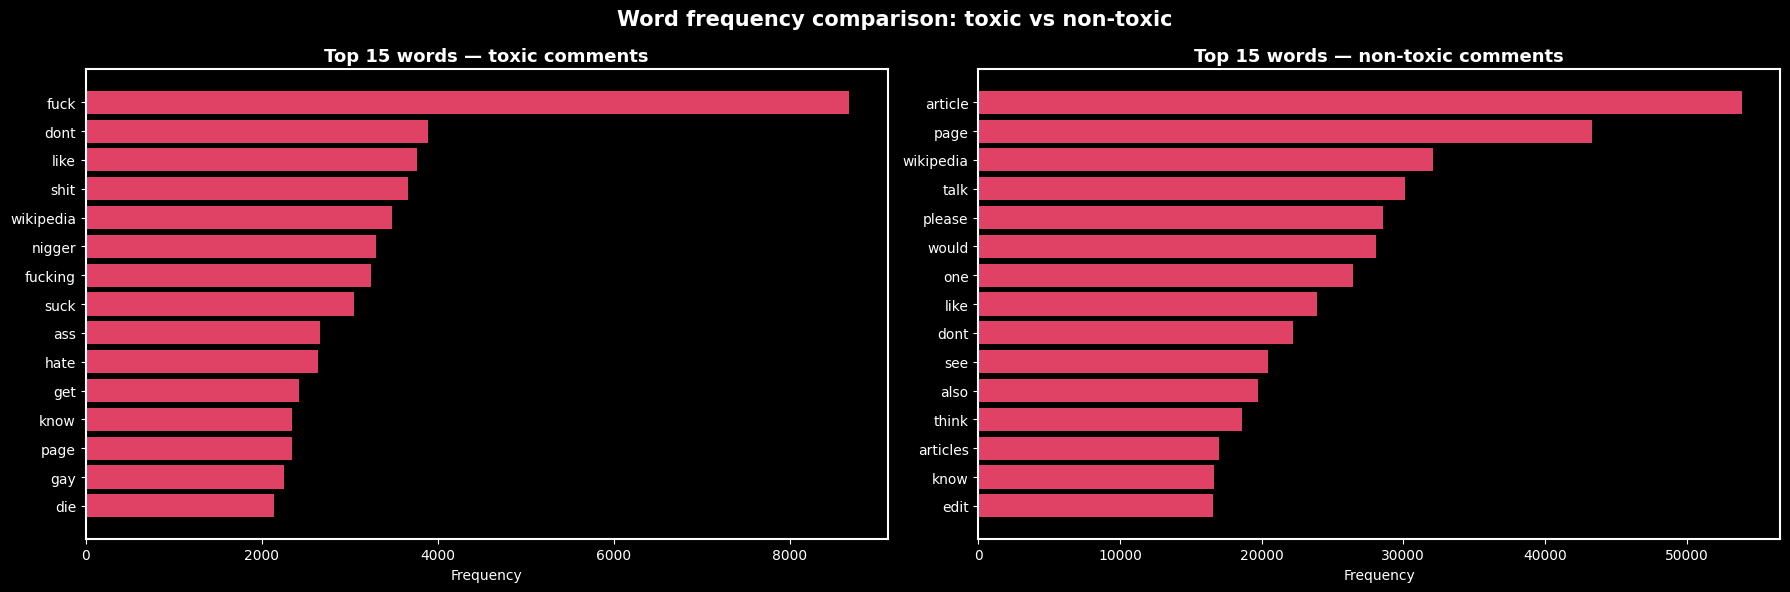

✅ Saved: chart8_top_words.png


In [14]:
from collections import Counter

def get_top_words(text_series, n=15):
    all_words = ' '.join(text_series.dropna()).split()
    filtered  = [w for w in all_words if w not in stop_words and len(w) > 2]
    return Counter(filtered).most_common(n)

toxic_words = get_top_words(df[df['toxicity_score'] > 0]['clean_comment'])
clean_words = get_top_words(df[df['toxicity_score'] == 0]['clean_comment'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(BG)

for ax_ in axes:
    ax_.set_facecolor(BG)
    for spine in ax_.spines.values():
        spine.set_edgecolor(FG); spine.set_linewidth(1.5)

words_t, counts_t = zip(*toxic_words)
axes[0].barh(list(words_t), list(counts_t), color=PINK)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 words — toxic comments', color=FG, fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency', color=FG)
axes[0].tick_params(colors=FG)

words_c, counts_c = zip(*clean_words)
axes[1].barh(list(words_c), list(counts_c), color=PINK)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 words — non-toxic comments', color=FG, fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency', color=FG)
axes[1].tick_params(colors=FG)

plt.suptitle('Word frequency comparison: toxic vs non-toxic', color=FG, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_top_words.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart8_top_words.png")

## 📊 Chart 9 — Correlation Heatmap

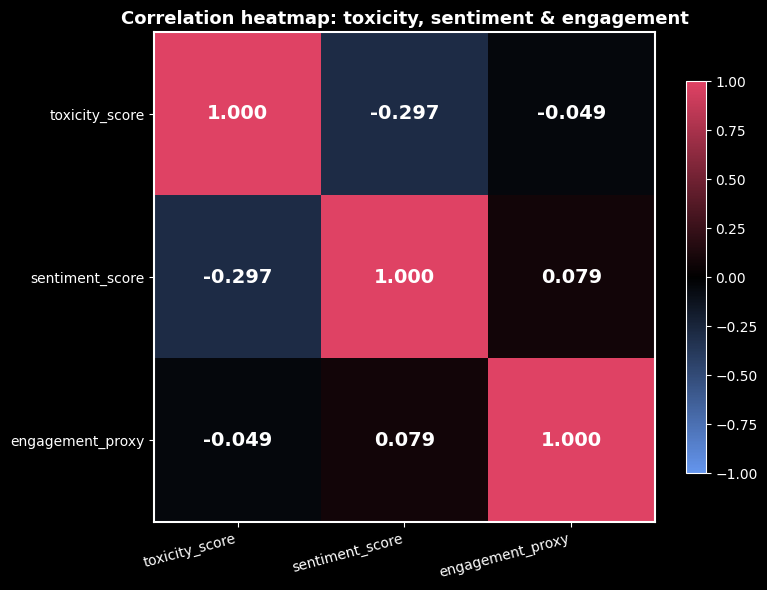


📊 Correlation Matrix:
                  toxicity_score  sentiment_score  engagement_proxy
toxicity_score             1.000           -0.297            -0.049
sentiment_score           -0.297            1.000             0.079
engagement_proxy          -0.049            0.079             1.000
✅ Saved: chart9_correlation_heatmap.png


In [20]:
corr_cols   = ['toxicity_score', 'sentiment_score', 'engagement_proxy']
corr_matrix = df[corr_cols].corr()

div_pink = LinearSegmentedColormap.from_list('dp', ['#6495ED', '#000000', '#df4264'], N=256)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

im = ax.imshow(corr_matrix.values, cmap=div_pink, vmin=-1, vmax=1, aspect='auto')
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.ax.yaxis.set_tick_params(color=FG)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.3f}',
                ha='center', va='center', fontsize=14, fontweight='bold', color=FG)

ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(corr_cols, color=FG, rotation=15, ha='right')
ax.set_yticklabels(corr_cols, color=FG)
for spine in ax.spines.values():
    spine.set_edgecolor(FG); spine.set_linewidth(1.5)

ax.set_title('Correlation heatmap: toxicity, sentiment & engagement',
             color=FG, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_correlation_heatmap.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("\n📊 Correlation Matrix:")
print(corr_matrix.round(3))
print("✅ Saved: chart9_correlation_heatmap.png")

## 📊 Chart 10 — Comment Length Histogram (Log Scale)

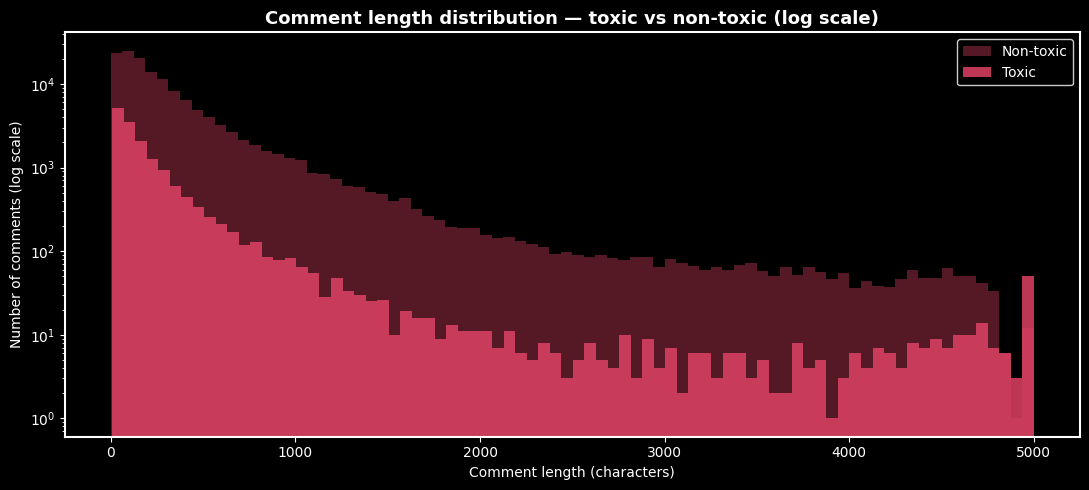

✅ Saved: chart10_comment_length_histogram.png


In [16]:
fig, ax = styled_fig(11, 5)

ax.hist(df[df['toxicity_score'] == 0]['engagement_proxy'],
        bins=80, color=PINK, alpha=0.38, label='Non-toxic', edgecolor='none')
ax.hist(df[df['toxicity_score'] > 0]['engagement_proxy'],
        bins=80, color=PINK, alpha=0.85, label='Toxic', edgecolor='none')

ax.set_yscale('log')
ax.set_title('Comment length distribution — toxic vs non-toxic (log scale)',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Comment length (characters)', color=FG)
ax.set_ylabel('Number of comments (log scale)', color=FG)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG)

plt.tight_layout()
plt.savefig('chart10_comment_length_histogram.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart10_comment_length_histogram.png")

## 📊 Chart 11 — Regression Model + Actual vs Predicted Scatter

📈 REGRESSION MODEL RESULTS
R² Score:               0.0073
Mean Squared Error:     294997.45

Coefficients:
  Toxicity Score:       -21.6275
  Sentiment Score:      68.0987
  Intercept:            366.7380


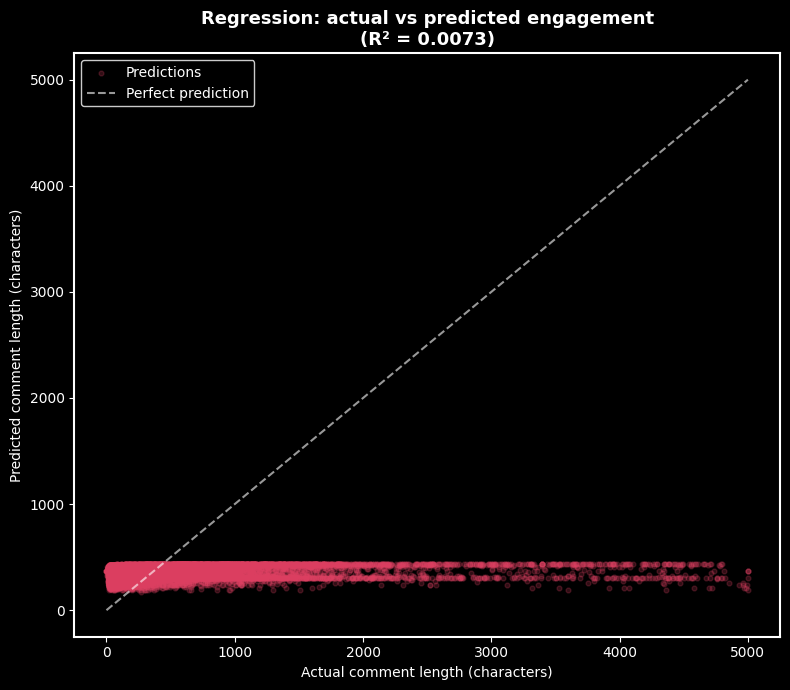

✅ Saved: chart11_regression_scatter.png


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df[['toxicity_score', 'sentiment_score']].copy()
y = df['engagement_proxy'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("📈 REGRESSION MODEL RESULTS")
print("=" * 40)
print(f"R² Score:               {r2:.4f}")
print(f"Mean Squared Error:     {mse:.2f}")
print(f"\nCoefficients:")
print(f"  Toxicity Score:       {model.coef_[0]:.4f}")
print(f"  Sentiment Score:      {model.coef_[1]:.4f}")
print(f"  Intercept:            {model.intercept_:.4f}")
print("=" * 40)

# ── Scatter chart ──
fig, ax = styled_fig(8, 7)

ax.scatter(y_test, y_pred, alpha=0.22, s=12, color=PINK, label='Predictions')

lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], color=FG, linestyle='--',
        linewidth=1.5, alpha=0.6, label='Perfect prediction')

ax.set_title(f'Regression: actual vs predicted engagement\n(R² = {r2:.4f})',
             color=FG, fontsize=13, fontweight='bold')
ax.set_xlabel('Actual comment length (characters)', color=FG)
ax.set_ylabel('Predicted comment length (characters)', color=FG)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG)

plt.tight_layout()
plt.savefig('chart11_regression_scatter.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print("✅ Saved: chart11_regression_scatter.png")

## 📋 Final Summary Report

In [18]:
print("\n" + "=" * 50)
print("📋 FINAL SUMMARY REPORT")
print("=" * 50)

total       = len(df)
toxic_count = len(df[df['toxicity_score'] > 0])
clean_count = len(df[df['toxicity_score'] == 0])

print(f"\n📊 Dataset Overview:")
print(f"   Total Comments:        {total:,}")
print(f"   Toxic Comments:        {toxic_count:,} ({toxic_count/total*100:.1f}%)")
print(f"   Non-Toxic Comments:    {clean_count:,} ({clean_count/total*100:.1f}%)")

avg_toxic_eng  = df[df['toxicity_score'] > 0]['engagement_proxy'].mean()
avg_clean_eng  = df[df['toxicity_score'] == 0]['engagement_proxy'].mean()
avg_toxic_sent = df[df['toxicity_score'] > 0]['sentiment_score'].mean()
avg_clean_sent = df[df['toxicity_score'] == 0]['sentiment_score'].mean()

print(f"\n📊 Engagement (Comment Length):")
print(f"   Avg Length - Toxic:     {avg_toxic_eng:.1f} chars")
print(f"   Avg Length - Non-Toxic: {avg_clean_eng:.1f} chars")

print(f"\n📊 Sentiment:")
print(f"   Avg Sentiment - Toxic:     {avg_toxic_sent:.4f}")
print(f"   Avg Sentiment - Non-Toxic: {avg_clean_sent:.4f}")

print(f"\n📊 Regression R² Score: {r2:.4f}")
print("\n✅ Full Analysis Complete! All charts saved.")
print("=" * 50)


📋 FINAL SUMMARY REPORT

📊 Dataset Overview:
   Total Comments:        159,571
   Toxic Comments:        16,225 (10.2%)
   Non-Toxic Comments:    143,346 (89.8%)

📊 Engagement (Comment Length):
   Avg Length - Toxic:     280.9 chars
   Avg Length - Non-Toxic: 376.9 chars

📊 Sentiment:
   Avg Sentiment - Toxic:     -0.4051
   Avg Sentiment - Non-Toxic: 0.1490

📊 Regression R² Score: 0.0073

✅ Full Analysis Complete! All charts saved.
